In [1]:
# imports
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Python/Datasets/AB_Test_Results.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


In [6]:
df.sample(10)

,USER_ID,VARIANT_NAME,REVENUE
1231,596,variant,0.0
268,5147,variant,0.0
9873,3298,control,0.0
1643,4819,variant,0.0
4839,4801,variant,0.0
7358,3960,control,0.0
2311,6014,variant,0.0
2232,1163,variant,0.0
7785,7638,control,0.0
1264,1488,variant,0.0


In [18]:
df.VARIANT_NAME.value_counts()

VARIANT_NAME
variant    5016
control    4984
Name: count, dtype: int64

In [39]:
groupa = df[df.VARIANT_NAME == 'control'].REVENUE
groupb = df[df.VARIANT_NAME == 'variant'].REVENUE

In [41]:
sts.ttest_ind(groupa, groupb)

TtestResult(statistic=np.float64(1.2711634519010084), pvalue=np.float64(0.20370007853373565), df=np.float64(9998.0))

In [51]:
doublevar = df.groupby(by='USER_ID')['VARIANT_NAME'].nunique().value_counts()
doublevar

VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64

In [53]:
doublevar / doublevar.sum()

VARIANT_NAME
1    0.756325
2    0.243675
Name: count, dtype: float64

In [74]:
singles = (df.groupby(by='USER_ID')['VARIANT_NAME'].nunique() == 1)
singles = singles[singles]
singles

USER_ID
2       True
4       True
5       True
6       True
9       True
        ... 
9990    True
9992    True
9993    True
9995    True
9998    True
Name: VARIANT_NAME, Length: 4783, dtype: bool

In [75]:
dfcleared = df[df.USER_ID.isin(singles.index)]

In [76]:
dfcleared

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
4,6174,variant,0.0
5,2380,variant,0.0
7,9168,control,0.0
9,7548,control,0.0
...,...,...,...
9993,2400,variant,0.0
9994,3129,control,0.0
9996,502,variant,0.0
9998,7741,control,0.0


In [78]:
sts.ttest_ind(a=dfcleared[dfcleared['VARIANT_NAME'] == 'control'].REVENUE, b = dfcleared[dfcleared['VARIANT_NAME'] == 'variant'].REVENUE)

TtestResult(statistic=np.float64(1.4075950071478767), pvalue=np.float64(0.1593022497674644), df=np.float64(6068.0))

<Axes: xlabel='VARIANT_NAME', ylabel='REVENUE'>

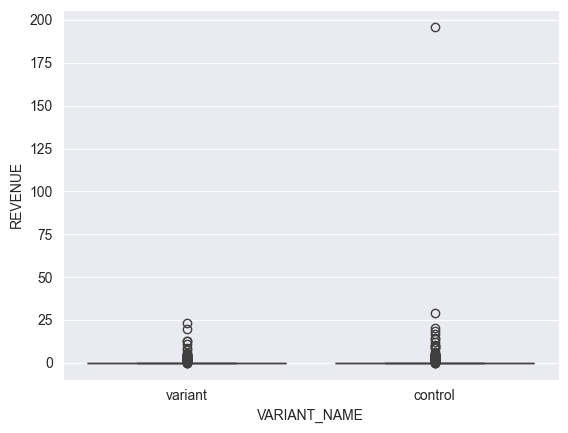

In [80]:
sns.boxplot(data=dfcleared, x='VARIANT_NAME', y='REVENUE')

In [85]:
dfcleared[dfcleared.REVENUE > 50].USER_ID

1437    3342
Name: USER_ID, dtype: int64

In [86]:
df1 = dfcleared[dfcleared.REVENUE < 50]

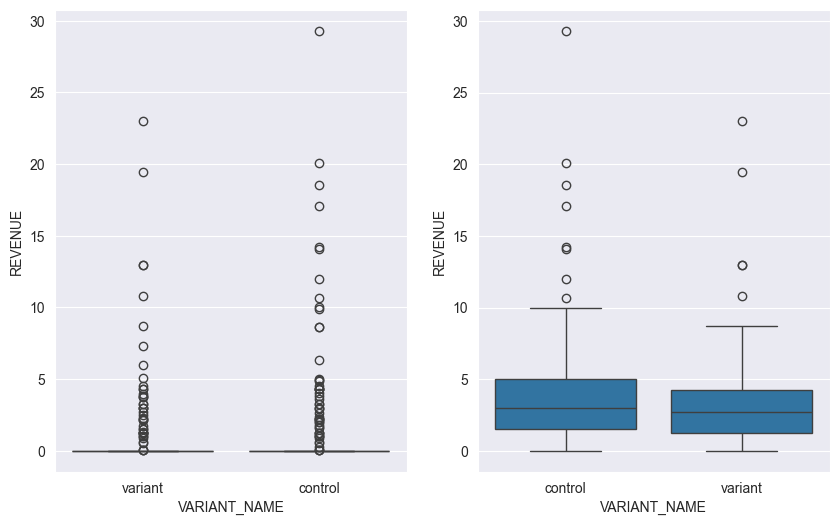

In [95]:
fig, axes = plt.subplots(figsize=(10,6), ncols=2)
sns.boxplot(data=df1, x='VARIANT_NAME', y='REVENUE', ax = axes[0])
sns.boxplot(data=df1[df1.REVENUE>0], x='VARIANT_NAME', y='REVENUE')
plt.show()

In [97]:
sts.ttest_ind(a=df1[df1.VARIANT_NAME == 'control'].REVENUE, b = df1[df1.VARIANT_NAME == 'variant'].REVENUE)

TtestResult(statistic=np.float64(1.367590650018532), pvalue=np.float64(0.17149090193658412), df=np.float64(6067.0))

In [100]:
df2 = df1.groupby(by=['USER_ID', 'VARIANT_NAME'], as_index=False).REVENUE.sum()

In [101]:
df2

,USER_ID,VARIANT_NAME,REVENUE
0,2,control,0.0
1,4,variant,0.0
2,5,variant,0.0
3,6,variant,0.0
4,9,variant,0.0
...,...,...,...
4777,9990,variant,0.0
4778,9992,control,0.0
4779,9993,control,0.0
4780,9995,variant,0.0


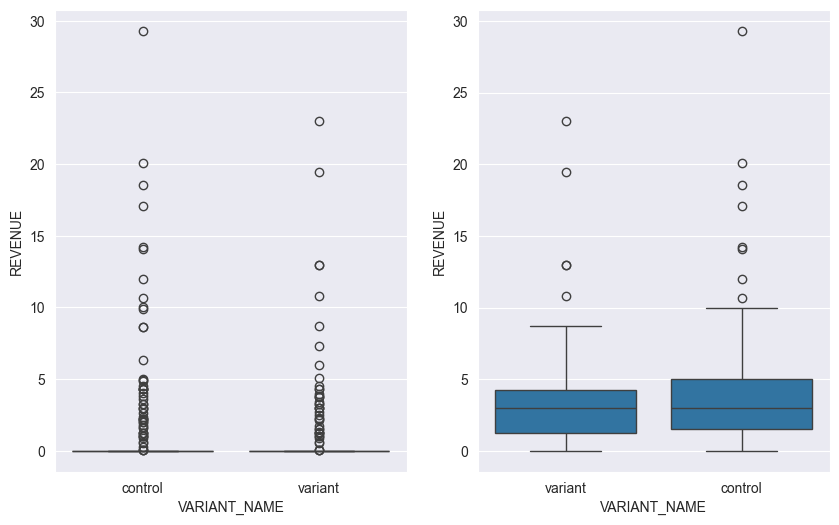

In [104]:
fig, axes = plt.subplots(figsize=(10,6), ncols=2)
sns.boxplot(data=df2, x='VARIANT_NAME', y='REVENUE', ax = axes[0])
sns.boxplot(data=df2[df2.REVENUE>0], x='VARIANT_NAME', y='REVENUE')
plt.show()

In [105]:
sts.ttest_ind(a=df2[df2.VARIANT_NAME == 'control'].REVENUE, b = df2[df2.VARIANT_NAME == 'variant'].REVENUE)

TtestResult(statistic=np.float64(1.353347564404142), pvalue=np.float64(0.1760086156257087), df=np.float64(4780.0))

In [106]:
sts.shapiro(df2[df2.VARIANT_NAME == 'variant'].REVENUE)

ShapiroResult(statistic=np.float64(0.06145986897942335), pvalue=np.float64(9.962810723092505e-76))

In [108]:
sts.mannwhitneyu(df2[df2.VARIANT_NAME == 'variant'].REVENUE, df2[df2.VARIANT_NAME == 'control'].REVENUE)

MannwhitneyuResult(statistic=np.float64(2845109.0), pvalue=np.float64(0.24799555106821947))

In [110]:
sts.mannwhitneyu(df2[(df2.VARIANT_NAME == 'variant') & (df2.REVENUE != 0)].REVENUE, df2[(df2.VARIANT_NAME == 'control') & (df2.REVENUE != 0)].REVENUE)

MannwhitneyuResult(statistic=np.float64(1029.0), pvalue=np.float64(0.5314192217084708))

In [111]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [ ]:
control = get_bootstrap_samples(df2[df2.VARIANT_NAME == 'control'].REVENUE.values, 10000)
variant = get_bootstrap_samples(df2[df2.VARIANT_NAME == 'control'].REVENUE.values, 10000)

In [129]:
control_paid = get_bootstrap_samples(df2[(df2.VARIANT_NAME == 'control') & (df2.REVENUE != 0)].REVENUE.values, 10000)
variant_paid = get_bootstrap_samples(df2[(df2.VARIANT_NAME == 'variant') & (df2.REVENUE != 0)].REVENUE.values, 10000)

<Axes: ylabel='Density'>

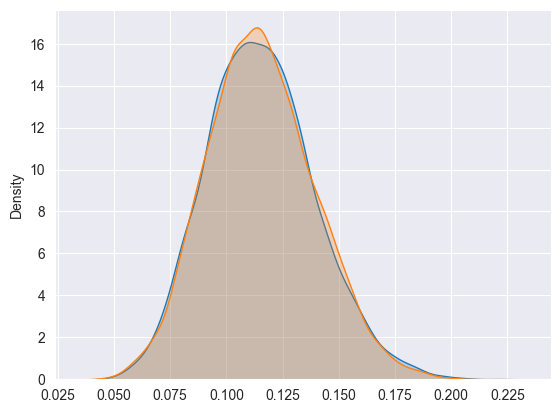

In [132]:
fig, axes = plt.subplots()
sns.kdeplot(np.mean(control, axis=1), fill=True, label='control')
sns.kdeplot(np.mean(variant, axis=1), fill=True, label='variant')

<Axes: ylabel='Density'>

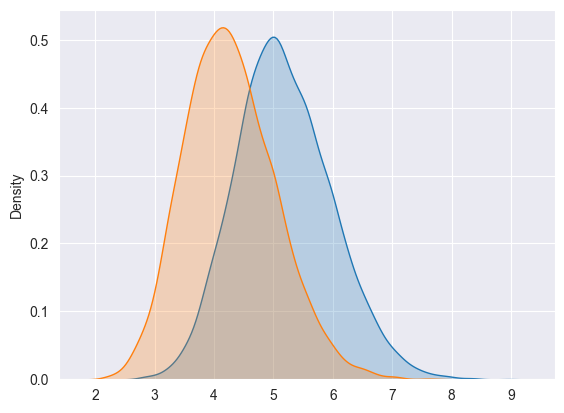

In [131]:
sns.kdeplot(np.mean(control_paid, axis=1), fill=True, label='control')
sns.kdeplot(np.mean(variant_paid, axis=1), fill=True, label='variant')

In [135]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """ Plot the distribution of the mean difference and return the confidence intervals """
    f, ax = plt.subplots()
    # get data for coloring confidence intervals
    points = sns.kdeplot(variant - control, fill=False).get_lines()[0].get_data()
    x = points[0]
    y = points[1]
    ymin, ymax = plt.ylim()
    # highlight the zero value and the bounds of the confidence interval
    plt.vlines(0, 0, ymax, label='0', color='gray')
    plt.vlines(stat_intervals(variant - control, alpha)[0], 0, ymax, linestyles="dashed")
    plt.vlines(stat_intervals(variant - control, alpha)[1], 0, ymax, linestyles="dashed")
    # color the confidence interval and zones outside it
    plt.fill_between(x,y,
                     where = (x >= stat_intervals(variant - control, alpha)[1]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = (x <= stat_intervals(variant - control, alpha)[0]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = ((x >= stat_intervals(variant - control, alpha)[0])
                              & (x <= stat_intervals(variant - control, alpha)[1])),
                     color='red',
                     label = '95% confidence interval')
    plt.title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}')
    plt.legend(prop={'size':13})
    # return confidence interval data
    return stat_intervals(variant - control)

array([-0.06626224,  0.06509115])

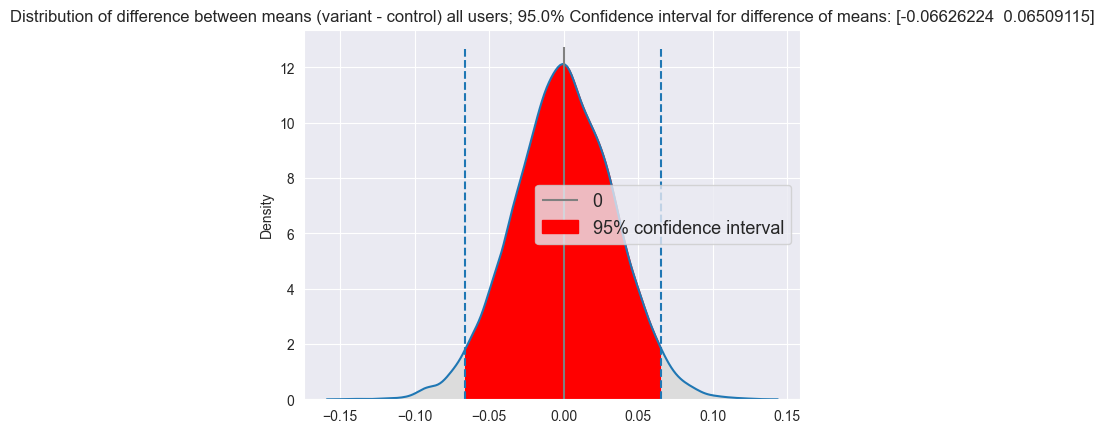

In [136]:
plot_distribution_and_stat_intervals(
    np.mean(variant, axis=1), 
    np.mean(control, axis=1),
    title='all users'
)

array([-3.06417206,  1.25804167])

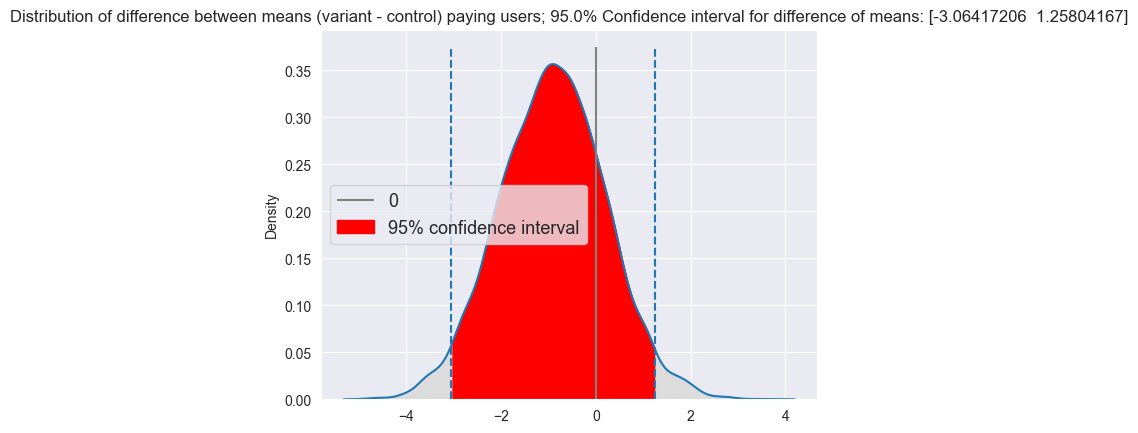

In [137]:
plot_distribution_and_stat_intervals(
    np.mean(variant_paid, axis=1), 
    np.mean(control_paid, axis=1), 
    title='paying users'
)